# **Project:** Consumer Beverage Survey Analysis 

## 1. Environment Setup & Data Loading

Import all required libraries and load the raw survey dataset.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [4]:
df = pd.read_csv('survey_results.csv')
print(df.shape)
df

(30010, 17)


,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30005,R29996,29,M,Metro,Working Professional,16L - 25L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Online,Simple,High (Very health-conscious),Social (eg. Parties),150-200
30006,R29997,42,F,Urban,Working Professional,> 35L,3-4 times,Established,Small (250 ml),2 to 4,Quality,Traditional,Online,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",200-250
30007,R29998,57,F,Metro,Retired,<10L,0-2 times,Established,Medium (500 ml),0 to 1,Price,Traditional,Retail Store,Premium,High (Very health-conscious),Casual (eg. At home),150-200
30008,R29999,23,M,Urban,Working Professional,16L - 25L,5-7 times,Established,Small (250 ml),above 4,Quality,Exotic,Online,Eco-Friendly,Medium (Moderately health-conscious),Social (eg. Parties),150-200


## 2. Initial Exploration

Understand the dataset structure, data types, and identify columns with missing values before any cleaning.

In [6]:
df.isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8064
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

import sweetviz as sv

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

In [8]:
df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

## 3. Data Cleaning

This section addresses data quality issues: duplicates, age outliers, missing values, and spelling inconsistencies.

---

### 3.1 Remove Duplicates

Check for fully duplicated rows across all columns and remove them to prevent data leakage in modeling.

In [10]:
df.duplicated().sum()

10

In [11]:
df.drop_duplicates(inplace=True)

### 3.2 Handle Missing Values

Three columns contain missing data:
- **`income_levels`** — filled with `'Not Reported'` (students and others may have no income)
- **`consume_frequency(weekly)`** — filled with the **mode** (most common frequency)
- **`purchase_channel`** — filled with the **mode** (most common channel)

In [13]:
df_income = df[df['income_levels'].isna()]
df_income.head(10)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100
5,R00006,22,F,Urban,Student,NaN,5-7 times,Established,Large (1 L),2 to 4,Price,Traditional,Online,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",100-150
11,R00012,23,F,Urban,Student,NaN,0-2 times,Established,Small (250 ml),0 to 1,Price,Exotic,Retail Store,Premium,Low (Not very concerned),Social (eg. Parties),50-100
14,R00015,22,M,Metro,Student,NaN,3-4 times,Established,Small (250 ml),0 to 1,Price,Traditional,Retail Store,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
20,R00021,23,M,Semi-Urban,Student,NaN,3-4 times,Newcomer,Large (1 L),0 to 1,Availability,Traditional,Retail Store,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
23,R00024,23,M,Urban,Student,NaN,0-2 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Retail Store,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
30,R00031,21,F,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),above 4,Price,Exotic,Online,Eco-Friendly,Medium (Moderately health-conscious),Social (eg. Parties),100-150
31,R00032,23,M,Urban,Student,NaN,0-2 times,Newcomer,Small (250 ml),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),50-100
34,R00035,18,M,Metro,Student,NaN,3-4 times,Newcomer,Large (1 L),0 to 1,Price,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),100-150
35,R00036,20,F,Rural,Student,NaN,3-4 times,Established,Small (250 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),50-100


In [14]:
df['income_levels'] = df['income_levels'].fillna('Not Reported')

In [15]:
df.groupby('occupation')['income_levels'].sum()

occupation
Entrepreneur            10L - 15L26L - 35L10L - 15L10L - 15L16L - 25L1...
Retired                 10L - 15L10L - 15L10L - 15L16L - 25L<10L<10L<1...
Student                 Not ReportedNot ReportedNot ReportedNot Report...
Working Professional    <10L> 35L> 35L16L - 25L<10L<10L<10L16L - 25L16...
Name: income_levels, dtype: object

In [16]:
df['consume_frequency(weekly)'] = df['consume_frequency(weekly)'].fillna(
    df['consume_frequency(weekly)'].mode()[0]
)

In [17]:
df['purchase_channel'] = df['purchase_channel'].fillna(
    df['purchase_channel'].mode()[0]
)

### 3.3 Fix Spelling Inconsistencies

Two columns contain typos and inconsistent casing:
- **`zone`** — `'Urbna'` → `'Urban'`, `'Metor'` → `'Metro'`
- **`current_brand`** — `'newcomer'` → `'Newcomer'`, `'Establishd'` → `'Established'`

In [19]:
df['zone'] = df['zone'].str.strip().str.title()

zone_mapping = {
    "Urbna": "Urban",
    "Metor": "Metro"
}

df['zone'] = df['zone'].replace(zone_mapping)

In [20]:
df['zone'].value_counts()

zone
Metro         11915
Urban         10693
Semi-Urban     5275
Rural          2117
Name: count, dtype: int64

In [21]:
df['current_brand'] = df['current_brand'].str.strip().str.title()

current_brand_mapping = {
    "newcomer": "Newcomer",
    "Establishd": "Established"
}

df['current_brand'] = df['current_brand'].replace(current_brand_mapping)

In [22]:
df['current_brand'].value_counts()

current_brand
Established    15467
Newcomer       14533
Name: count, dtype: int64

In [23]:
df.shape


(30000, 17)

cat_cols = df.columns

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(col)

plt.tight_layout()
plt.show()

---

## 4. Feature Engineering

Four new features are created to enrich the dataset for downstream modeling:

| Feature | Description |
|---|---|
| `age_group` | Binned age categories |
| `cf_ab_score` | Consume Frequency vs Brand Awareness ratio |
| `zas_score` | Zone × Income affluence score |
| `bsi` | Binary brand switching indicator |

---

### 4.1 Age Group Categorization

The `age` column is binned into 6 meaningful age groups. After creating the new column, the original `age` column is dropped.

In [26]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 70, float('inf')],
    labels=['18-25', '26-35', '36-45', '46-55', '56-70', '70+']
)

In [27]:
print(df.shape)
df.head()

(30000, 18)


,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35
4,R00005,23,M,Metro,Student,Not Reported,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25


In [28]:
df = df.drop(columns=['age'])

In [29]:
df['age_group'].value_counts()

age_group
18-25    10468
26-35     9093
36-45     5972
46-55     2966
56-70     1492
70+          9
Name: count, dtype: int64

### 4.2 Consume Frequency & Awareness Brand Score (CF_AB_Score)

This score captures the ratio of consumption frequency relative to combined frequency and brand awareness.

**Formula:**
$$\text{cf\_ab\_score} = \frac{\text{frequency score}}{\text{frequency score} + \text{awareness score}}$$

| consume_frequency(weekly) | Score | | awareness_of_other_brands | Score |
|---|---|---|---|---|
| 0-2 times | 1 | | 0 to 1 | 1 |
| 3-4 times | 2 | | 2 to 4 | 2 |
| 5-7 times | 3 | | above 4 | 3 |

In [31]:
cf_map = {
    "0-2 times": 1,
    "3-4 times": 2,
    "5-7 times": 3
}

ab_map = {
    "0 to 1": 1,
    "2 to 4": 2,
    "above 4": 3
}

In [32]:
df['cf_num'] = df['consume_frequency(weekly)'].map(cf_map)
df['ab_num'] = df['awareness_of_other_brands'].map(ab_map)

In [33]:
df['cf_ab_score'] = (
    df['cf_num'] / (df['cf_num'] + df['ab_num'])
).round(2)

In [34]:
df[['cf_num', 'ab_num', 'cf_ab_score']].head()

,cf_num,ab_num,cf_ab_score
0,2,1,0.67
1,3,2,0.60
2,2,2,0.50
3,3,1,0.75
4,2,1,0.67


In [35]:
df['cf_ab_score'].describe()

count    30000.000000
mean         0.537318
std          0.141870
min          0.250000
25%          0.500000
50%          0.500000
75%          0.670000
max          0.750000
Name: cf_ab_score, dtype: float64

### 4.3 Zone Affluence Score (ZAS)

Combines geographic zone and income level to create a composite affluence indicator.

**Formula:**
$$\text{zas\_score} = \text{zone score} \times \text{income score}$$

| Zone | Score | | Income Level | Score |
|---|---|---|---|---|
| Rural | 1 | | < 10L | 1 |
| Semi-Urban | 2 | | 10L - 15L | 2 |
| Urban | 3 | | 16L - 25L | 3 |
| Metro | 4 | | 26L - 35L | 4 |
| | | | > 35L | 5 |
| | | | Not Reported | 0 |

In [37]:
zone_map = {
    "Rural": 1,
    "Semi-Urban": 2,
    "Urban": 3,
    "Metro": 4
}

income_map = {
    "<10L": 1,
    "10L - 15L": 2,
    "16L - 25L": 3,
    "26L - 35L": 4,
    "> 35L": 5,
    "Not Reported": 0,
}

In [38]:
df['income_levels'] = df['income_levels'].str.strip()

In [39]:
df['zone_num'] = df['zone'].map(zone_map)
df['income_num'] = df['income_levels'].map(income_map)

In [40]:
df['zas_score'] = df['zone_num'] * df['income_num']

In [41]:
df[['zone_num', 'income_num', 'zas_score']].head()
df['zas_score'].describe()

count    30000.000000
mean         6.097333
std          5.517953
min          0.000000
25%          0.000000
50%          6.000000
75%          9.000000
max         20.000000
Name: zas_score, dtype: float64

In [42]:
df['zas_score'].nunique()

14

### 4.4 Brand Switching Indicator (BSI)

A binary flag that identifies respondents likely to switch brands.

**Logic:**  
`bsi = 1` if **both** conditions are true:
- `current_brand` ≠ `'Established'`
- `reasons_for_choosing_brands` ∈ `['Price', 'Quality']`

Otherwise `bsi = 0`.

In [44]:
df['bsi'] = (
    (df['current_brand'] != 'Established') &
    (df['reasons_for_choosing_brands'].isin(['Price', 'Quality']))
).astype(int)

In [45]:
df['bsi'].value_counts()

bsi
0    20822
1     9178
Name: count, dtype: int64

In [46]:
df[
    (df['current_brand'] != 'Established') &
    (df['reasons_for_choosing_brands'].isin(['Price', 'Quality']))
]['bsi'].value_counts()

bsi
1    9178
Name: count, dtype: int64

---

## 5. Final Cleaning — Removing Logical Outliers

Some records have logically inconsistent occupation + age combinations. Based on domain knowledge:

| Condition | Reason |
|---|---|
| `occupation = 'Student'` AND `age_group = '56-70'` | Students are unlikely to be aged 56–70 |
| `age_group = '70+'` | Outside the survey's target population |

These records are removed from the final clean dataset.

In [48]:
outlier_conditions = (
    # existing
    ((df['age_group'] == '56-70') & (df['occupation'] == 'Student')) |
    ((df['age_group'] == '70+') 
)
)
df_clean = df[~outlier_conditions].copy()

In [49]:
pd.crosstab(df_clean['age_group'], df_clean['occupation'])

occupation,Entrepreneur,Retired,Student,Working Professional
age_group,,,,
18-25,535,0,7328,2605
26-35,1826,0,697,6570
36-45,1619,0,0,4353
46-55,799,0,0,2167
56-70,221,1130,0,106


In [50]:
(df_clean['bsi'] == 0).sum()

20796

In [51]:
df_clean['bsi'].value_counts()

bsi
0    20796
1     9160
Name: count, dtype: int64

In [52]:
df_clean.head()

,respondent_id,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,...,typical_consumption_situations,price_range,age_group,cf_num,ab_num,cf_ab_score,zone_num,income_num,zas_score,bsi
0,R00001,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,...,"Active (eg. Sports, gym)",100-150,26-35,2,1,0.67,3,1,3,1
1,R00002,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,...,Social (eg. Parties),200-250,46-55,3,2,0.60,4,5,20,0
2,R00003,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,...,"Active (eg. Sports, gym)",200-250,36-45,2,2,0.50,1,5,5,0
3,R00004,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,...,"Active (eg. Sports, gym)",150-200,26-35,3,1,0.75,3,3,9,0
4,R00005,M,Metro,Student,Not Reported,3-4 times,Established,Medium (500 ml),0 to 1,Availability,...,"Active (eg. Sports, gym)",50-100,18-25,2,1,0.67,4,0,0,0


In [53]:
df_clean.describe()

,cf_num,ab_num,cf_ab_score,zone_num,income_num,zas_score,bsi
count,29956.000000,29956.000000,29956.000000,29956.000000,29956.000000,29956.000000,29956.000000
mean,2.045400,1.761350,0.537360,3.080451,1.989318,6.103652,0.305782
std,0.777506,0.754111,0.141876,0.921273,1.617718,5.517243,0.460745
min,1.000000,1.000000,0.250000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.500000,3.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,0.500000,3.000000,2.000000,6.000000,0.000000
75%,3.000000,2.000000,0.670000,4.000000,3.000000,9.000000,1.000000
max,3.000000,3.000000,0.750000,4.000000,5.000000,20.000000,1.000000


In [54]:
categorical_columns = df_clean.select_dtypes(['object']).columns
categorical_columns

Index(['respondent_id', 'gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'price_range'],
      dtype='object')

In [55]:
for col in categorical_columns:
    print(col,":",df_clean[col].unique())

respondent_id : ['R00001' 'R00002' 'R00003' ... 'R29998' 'R29999' 'R30000']
gender : ['M' 'F']
zone : ['Urban' 'Metro' 'Rural' 'Semi-Urban']
occupation : ['Working Professional' 'Student' 'Entrepreneur' 'Retired']
income_levels : ['<10L' '> 35L' '16L - 25L' 'Not Reported' '10L - 15L' '26L - 35L']
consume_frequency(weekly) : ['3-4 times' '5-7 times' '0-2 times']
current_brand : ['Newcomer' 'Established']
preferable_consumption_size : ['Medium (500 ml)' 'Large (1 L)' 'Small (250 ml)']
awareness_of_other_brands : ['0 to 1' '2 to 4' 'above 4']
reasons_for_choosing_brands : ['Price' 'Quality' 'Availability' 'Brand Reputation']
flavor_preference : ['Traditional' 'Exotic']
purchase_channel : ['Online' 'Retail Store']
packaging_preference : ['Simple' 'Premium' 'Eco-Friendly']
health_concerns : ['Medium (Moderately health-conscious)' 'Low (Not very concerned)'
 'High (Very health-conscious)']
typical_consumption_situations : ['Active (eg. Sports, gym)' 'Social (eg. Parties)' 'Casual (eg. At hom

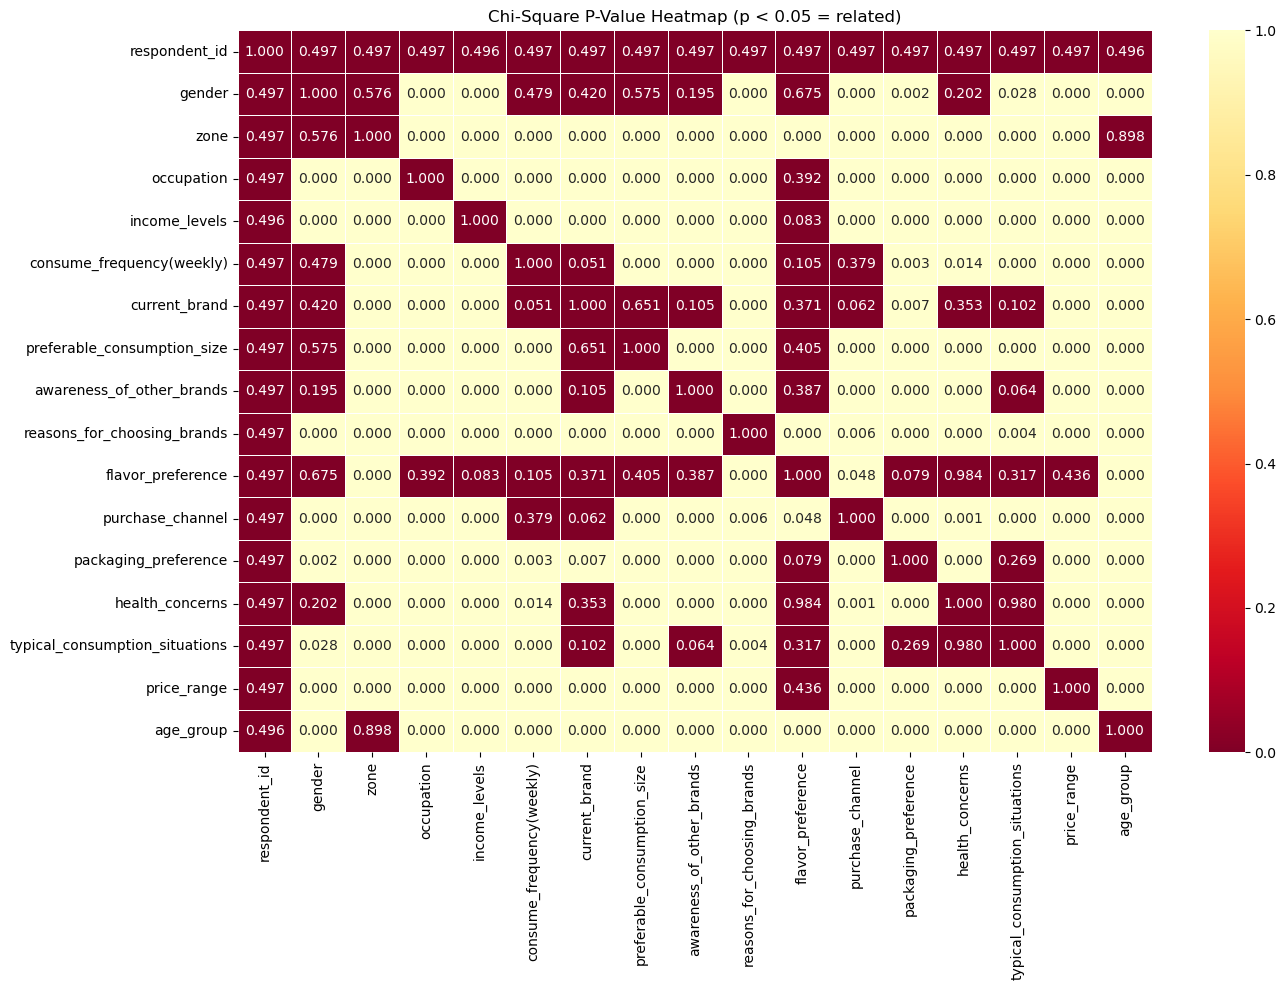

In [56]:
from scipy.stats import chi2_contingency

cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Build a p-value matrix
import numpy as np

pval_matrix = pd.DataFrame(np.ones((len(cat_cols), len(cat_cols))), 
                            index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 != col2:
            ct = pd.crosstab(df_clean[col1], df_clean[col2])
            chi2, p, _, _ = chi2_contingency(ct)
            pval_matrix.loc[col1, col2] = p

# Plot — lower p-value = stronger relationship
plt.figure(figsize=(14, 10))
sns.heatmap(
    pval_matrix < 0.05,   # True = significant relationship
    annot=pval_matrix.round(3),
    fmt=".3f",
    cmap="YlOrRd_r",
    linewidths=0.5
)
plt.title("Chi-Square P-Value Heatmap (p < 0.05 = related)")
plt.tight_layout()
plt.show()

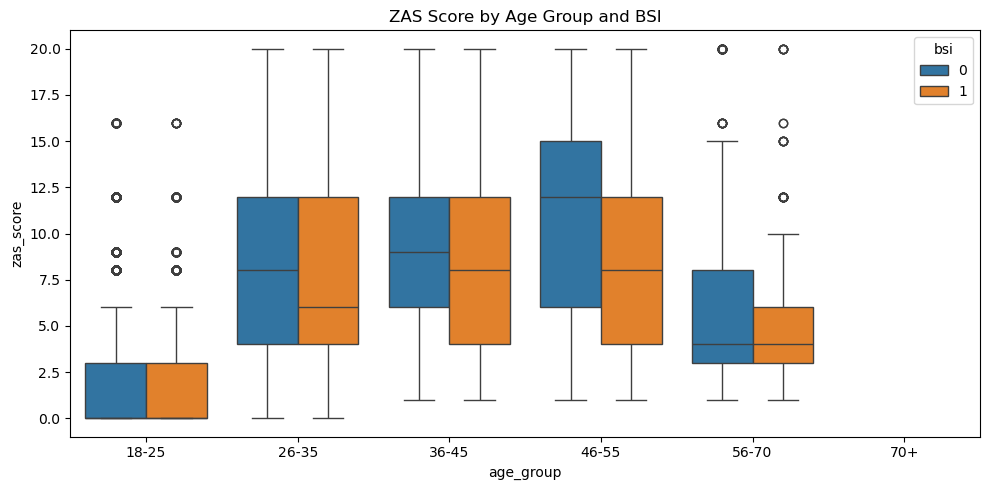

In [57]:
# Example: How does BSI vary across age_group?
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='age_group', y='zas_score', hue='bsi')
plt.title('ZAS Score by Age Group and BSI')
plt.tight_layout()
plt.show()

💡 Business Recommendation
Target BSI=1 (switchers) marketing at:
✅ Age 26-45 with low ZAS score → price-sensitive, open to switching
✅ Age 18-25 → ZAS doesn't matter here, focus on Price/Quality messaging

Retain BSI=0 (loyal) customers by:
✅ Age 46-55 with high ZAS → premium loyalty programs work here
✅ These are your most valuable, stable customers

In [59]:
# Drop all intermediate helper columns created during feature engineering
cols_to_drop = ['cf_num', 'ab_num', 'zone_num', 'income_num']
existing_drops = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drops)

# Convert age_group from category dtype to string so .map() works
df_clean['age_group'] = df_clean['age_group'].astype(str)

print("Columns now:", df_clean.columns.tolist())
print("Dtypes:\n", df_clean.dtypes)
print("Nulls:\n", df_clean.isnull().sum())

Columns now: ['respondent_id', 'gender', 'zone', 'occupation', 'income_levels', 'consume_frequency(weekly)', 'current_brand', 'preferable_consumption_size', 'awareness_of_other_brands', 'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel', 'packaging_preference', 'health_concerns', 'typical_consumption_situations', 'price_range', 'age_group', 'cf_ab_score', 'zas_score', 'bsi']
Dtypes:
 respondent_id                      object
gender                             object
zone                               object
occupation                         object
income_levels                      object
consume_frequency(weekly)          object
current_brand                      object
preferable_consumption_size        object
awareness_of_other_brands          object
reasons_for_choosing_brands        object
flavor_preference                  object
purchase_channel                   object
packaging_preference               object
health_concerns                    object
typic

# STEP 1:  Define Features (X) and Target (y)

## Target Variable

In [62]:
y = df_clean['price_range']

## Feature Matrix

In [64]:
X = df_clean.drop(columns=['price_range' , 'respondent_id'])

In [65]:
print(X.shape)
print(y.shape)

(29956, 18)
(29956,)


# STEP 2: Train-Test Split

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [68]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(22467, 18) (7489, 18)
(22467,) (7489,)


# STEP 3A: Label Encode Selected Columns

In [70]:
X_train['health_concerns'].unique()

array(['Low (Not very concerned)', 'Medium (Moderately health-conscious)',
       'High (Very health-conscious)'], dtype=object)

In [71]:
# ---- age_group (ordered low to high) ----
age_group_map = {
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-55': 4,
    '56-70': 5,
    '70+':   6
}

# ---- income_levels (ordered low to high) ----
income_map = {
    'Not Reported': 0,
    '<10L':         1,
    '10L - 15L':    2,
    '16L - 25L':    3,
    '26L - 35L':    4,
    '> 35L':        5
}

# ---- health_concerns (ordered low to high) ----
health_map = {
    'Low (Not very concerned)':           1,
    'Medium (Moderately health-conscious)': 2,
    'High (Very health-conscious)':        3
}

# ---- consume_frequency weekly (ordered low to high) ----
freq_map = {
    '0-2 times': 1,
    '3-4 times': 2,
    '5-7 times': 3
}

# ---- preferable_consumption_size (ordered small to large) ----
size_map = {
    'Small (250 ml)':  1,
    'Medium (500 ml)': 2,
    'Large (1 L)':     3
}

# ---- target variable: price_range ----
price_map = {
    '50-100':  0,
    '100-150': 1,
    '150-200': 2,
    '200-250': 3
}

In [72]:
# Apply to train and test separately
for df_split in [X_train, X_test]:
    df_split['age_group']                  = df_split['age_group'].map(age_group_map)
    df_split['income_levels']              = df_split['income_levels'].map(income_map)
    df_split['health_concerns']            = df_split['health_concerns'].map(health_map)
    df_split['consume_frequency(weekly)']  = df_split['consume_frequency(weekly)'].map(freq_map)
    df_split['preferable_consumption_size']= df_split['preferable_consumption_size'].map(size_map)

# Encode target
y_train = y_train.map(price_map)
y_test  = y_test.map(price_map)

print("encoding done!")


encoding done!


In [73]:

X_train.head()

,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,age_group,cf_ab_score,zas_score,bsi
8391,F,Semi-Urban,Working Professional,2,1,Newcomer,1,above 4,Availability,Traditional,Online,Simple,1,Social (eg. Parties),1,0.25,4,0
26395,F,Urban,Working Professional,3,3,Established,2,2 to 4,Quality,Traditional,Online,Premium,2,Social (eg. Parties),1,0.60,9,0
11276,F,Urban,Student,0,2,Newcomer,1,2 to 4,Price,Traditional,Online,Simple,2,"Active (eg. Sports, gym)",1,0.50,0,1
9110,M,Metro,Working Professional,3,2,Established,3,2 to 4,Quality,Traditional,Online,Premium,1,"Active (eg. Sports, gym)",2,0.50,12,0
3373,M,Metro,Entrepreneur,3,1,Established,3,above 4,Brand Reputation,Traditional,Online,Eco-Friendly,2,Casual (eg. At home),2,0.25,12,0


In [74]:
X_train.isnull().sum()

gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
age_group                         0
cf_ab_score                       0
zas_score                         0
bsi                               0
dtype: int64

In [75]:
X_train.dtypes

gender                             object
zone                               object
occupation                         object
income_levels                       int64
consume_frequency(weekly)           int64
current_brand                      object
preferable_consumption_size         int64
awareness_of_other_brands          object
reasons_for_choosing_brands        object
flavor_preference                  object
purchase_channel                   object
packaging_preference               object
health_concerns                     int64
typical_consumption_situations     object
age_group                           int64
cf_ab_score                       float64
zas_score                           int64
bsi                                 int32
dtype: object

In [76]:
cat_cols = X_train.select_dtypes(include='object').columns
cat_cols

Index(['gender', 'zone', 'occupation', 'current_brand',
       'awareness_of_other_brands', 'reasons_for_choosing_brands',
       'flavor_preference', 'purchase_channel', 'packaging_preference',
       'typical_consumption_situations'],
      dtype='object')

In [77]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

In [78]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [79]:
X_train.dtypes

income_levels                                            int64
consume_frequency(weekly)                                int64
preferable_consumption_size                              int64
health_concerns                                          int64
age_group                                                int64
cf_ab_score                                            float64
zas_score                                                int64
bsi                                                      int32
gender_M                                                  bool
zone_Rural                                                bool
zone_Semi-Urban                                           bool
zone_Urban                                                bool
occupation_Retired                                        bool
occupation_Student                                        bool
occupation_Working Professional                           bool
current_brand_Newcomer                                 

In [80]:
y_test.shape

(7489,)

In [81]:
y_train.shape

(22467,)

In [82]:

X_test.shape

(7489, 27)

In [83]:
X_train.shape

(22467, 27)

In [84]:
X_vif = X_train.select_dtypes(include=['int64', 'float64']).copy()

In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [86]:
import statsmodels.api as sm

X_vif = sm.add_constant(X_vif)

In [87]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,feature,VIF
0,const,31.098685
1,income_levels,5.827988
2,consume_frequency(weekly),2.063579
3,preferable_consumption_size,1.072551
4,health_concerns,1.028318
5,age_group,1.352940
6,cf_ab_score,2.095716
7,zas_score,5.793157


In [88]:
vif_data = vif_data[vif_data['feature'] != 'const']
vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
1,income_levels,5.827988
7,zas_score,5.793157
6,cf_ab_score,2.095716
2,consume_frequency(weekly),2.063579
5,age_group,1.352940
3,preferable_consumption_size,1.072551
4,health_concerns,1.028318


In [89]:
X_train.columns = X_train.columns.str.replace(' ', '_')
X_test.columns = X_test.columns.str.replace(' ', '_')

# STEP 4: Model Training 

In [91]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Logistic Regression

In [93]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8461743891040192
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       906
           1       0.81      0.82      0.82      1930
           2       0.81      0.80      0.81      2223
           3       0.91      0.91      0.91      2430

    accuracy                           0.85      7489
   macro avg       0.84      0.84      0.84      7489
weighted avg       0.85      0.85      0.85      7489



In [94]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9007878221391374
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       906
           1       0.89      0.87      0.88      1930
           2       0.86      0.89      0.87      2223
           3       0.94      0.94      0.94      2430

    accuracy                           0.90      7489
   macro avg       0.90      0.90      0.90      7489
weighted avg       0.90      0.90      0.90      7489



In [95]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM
Accuracy: 0.8536520229670183
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       906
           1       0.80      0.84      0.82      1930
           2       0.81      0.84      0.82      2223
           3       0.93      0.91      0.92      2430

    accuracy                           0.85      7489
   macro avg       0.86      0.84      0.85      7489
weighted avg       0.86      0.85      0.85      7489



In [96]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy: 0.5803177994391775
              precision    recall  f1-score   support

           0       0.45      0.91      0.60       906
           1       0.48      0.31      0.38      1930
           2       0.58      0.35      0.44      2223
           3       0.70      0.88      0.78      2430

    accuracy                           0.58      7489
   macro avg       0.55      0.61      0.55      7489
weighted avg       0.58      0.58      0.55      7489



In [97]:
xgb = XGBClassifier( eval_metric='mlogloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.9222860194952597
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       906
           1       0.92      0.90      0.91      1930
           2       0.89      0.91      0.90      2223
           3       0.96      0.95      0.95      2430

    accuracy                           0.92      7489
   macro avg       0.92      0.92      0.92      7489
weighted avg       0.92      0.92      0.92      7489



In [98]:
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000729 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 27
[LightGBM] [Info] Start training from score -2.100810
[LightGBM] [Info] Start training from score -1.343386
[LightGBM] [Info] Start training from score -1.228925
[LightGBM] [Info] Start training from score -1.126779
LightGBM
Accuracy: 0.9240218987848845
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       906
           1       0.91      0.90      0.91      1930
           2       0.90      0.92      0.91      2223
           3       0.96      0.96      0.96      2430

    accuracy                           0.92      7489
   macro avg       0.92      0.92      0.92      7489
weighted avg   

In [99]:
from sklearn.metrics import accuracy_score

results = {}

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "Naive Bayes": nb,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

results

{'Logistic Regression': 0.8461743891040192,
 'Random Forest': 0.9007878221391374,
 'SVM': 0.8536520229670183,
 'Naive Bayes': 0.5803177994391775,
 'XGBoost': 0.9222860194952597,
 'LightGBM': 0.9240218987848845}

In [100]:
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
5,LightGBM,0.924022
4,XGBoost,0.922286
1,Random Forest,0.900788
2,SVM,0.853652
0,Logistic Regression,0.846174
3,Naive Bayes,0.580318


In [101]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [102]:
def evaluate_regression_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mse, rmse, r2

In [103]:
reg_results = {}

for name, model in models.items():
    mse, rmse, r2 = evaluate_regression_metrics(model, X_test, y_test)
    
    reg_results[name] = {
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

pd.DataFrame(reg_results).T

,MSE,RMSE,R2
Logistic Regression,0.153826,0.392206,0.851434
Random Forest,0.099212,0.314980,0.904180
SVM,0.146348,0.382555,0.858656
Naive Bayes,0.524102,0.723949,0.493819
XGBoost,0.077714,0.278772,0.924943
LightGBM,0.075978,0.275641,0.926620


# Model Selection Summary:

Multiple models were trained including Logistic Regression, Random Forest, SVM, Naive Bayes, XGBoost, and LightGBM.
Among all models, LightGBM achieved the highest accuracy (~92.4%).
It also showed balanced precision and recall across all classes.
Therefore, LightGBM was selected as the final model.

#  Business Insight (this makes you stand out 🔥)

- Customers in higher price ranges are predicted more accurately
- Model captures behavioral + demographic patterns well
- Useful for pricing strategy and customer segmentation

In [106]:
import pandas as pd

feature_importance = pd.Series(lgbm.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(10)

consume_frequency(weekly)            1579
health_concerns                      1315
age_group                            1045
income_levels                         932
zas_score                             882
packaging_preference_Premium          839
cf_ab_score                           812
current_brand_Newcomer                679
bsi                                   591
awareness_of_other_brands_above_4     539
dtype: int32

<Axes: >

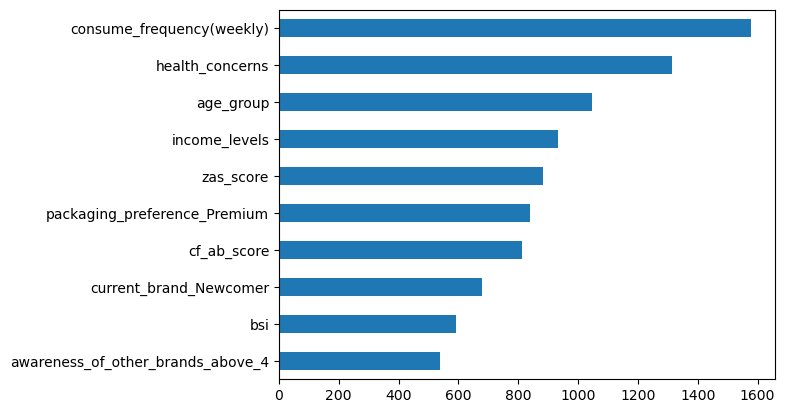

In [107]:
feature_importance.sort_values(ascending=True).tail(10).plot(kind='barh')

In [108]:
y_pred = lgbm.predict(X_test)

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Abs_Error"] = error_df["Error"].abs()

error_df.head()

,Actual,Predicted,Error,Abs_Error
11981,0,1,-1,1
1805,2,2,0,0
517,3,3,0,0
3820,3,3,0,0
28625,3,3,0,0


In [109]:
error_df["Error"].value_counts().sort_index()

Error
-1     305
 0    6920
 1     264
Name: count, dtype: int64

In [110]:
print("Exact match:", (error_df["Abs_Error"] == 0).mean())
print("Within ±1:", (error_df["Abs_Error"] <= 1).mean())
print("Within ±2:", (error_df["Abs_Error"] <= 2).mean())

Exact match: 0.9240218987848845
Within ±1: 1.0
Within ±2: 1.0


In [111]:
error_df.groupby("Actual")["Abs_Error"].mean()

Actual
0    0.090508
1    0.101554
2    0.083671
3    0.043210
Name: Abs_Error, dtype: float64

In [112]:
error_df.sort_values(by="Abs_Error", ascending=False).head(10)

,Actual,Predicted,Error,Abs_Error
11981,0,1,-1,1
25860,0,1,-1,1
18000,0,1,-1,1
7007,2,3,-1,1
22502,0,1,-1,1
17710,3,2,1,1
18916,3,2,1,1
12982,3,2,1,1
19172,3,2,1,1
10762,1,2,-1,1


### Error analysis shows that the model rarely makes large mistakes. Most misclassifications are within adjacent price ranges (±1), which is acceptable since the target is ordinal. This indicates that the model captures relative ordering effectively

import dagshub

dagshub.init(
    repo_owner="Krushang010",
    repo_name="Beverage_Price_Prediction",
    mlflow=True
)

import mlflow

mlflow.set_tracking_uri("https://dagshub.com/Krushang010/Beverage_Price_Prediction.mlflow")

mlflow.set_experiment("Beverage Price Prediction")  # 🔥 MUST ADD THIS

with mlflow.start_run():
    mlflow.log_metric("test_metric", 1)

from sklearn.metrics import accuracy_score, mean_squared_error
import numpy as np

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "Gaussian Naive Bayes": nb,
    "LightGBM": lgbm,
    "XGBoost": xgb
}

for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # Train
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        # Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)

        # Log parameters
        mlflow.log_param("model_name", name)

        # Log model
        mlflow.sklearn.log_model(model, name=name)

In [121]:
from lightgbm import LGBMClassifier
import pickle

# Best params from earlier tuning
best_params = {
    'subsample': 0.7,
    'num_leaves': 63,
    'n_estimators': 500,
    'min_child_samples': 10,
    'max_depth': 4,
    'learning_rate': 0.1,
    'colsample_bytree': 0.8
}

lgbm_best = LGBMClassifier(**best_params, random_state=42, verbose=-1)
lgbm_best.fit(X_train, y_train)

with open('lgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm_best, f)

print("✅ Tuned model saved!")

✅ Tuned model saved!


In [123]:
import streamlit
import pandas as pd
import numpy as np
import lightgbm as lgb
import sklearn

print(f"streamlit : {streamlit.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"numpy     : {np.__version__}")
print(f"lightgbm  : {lgb.__version__}")
print(f"sklearn   : {sklearn.__version__}")

streamlit : 1.37.1
pandas    : 2.2.2
numpy     : 1.26.4
lightgbm  : 4.6.0
sklearn   : 1.5.1
